In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## Dataset
https://www.kaggle.com/datasets/jainilcoder/online-payment-fraud-detection
https://www.kaggle.com/datasets/kartik2112/fraud-detection

In [2]:
df = pd.read_csv("onlinefraud.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.shape

(6362620, 11)

In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.dropna()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [35]:
df = df.drop_duplicates()


## Outliers handling

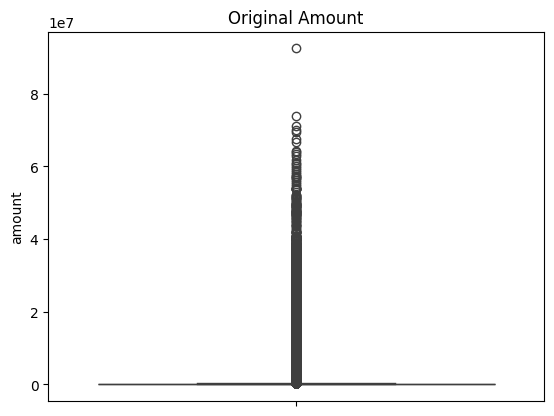

In [10]:
#for amount
sns.boxplot(y=df['amount'])
plt.title("Original Amount")
plt.show()

In [11]:
#log transform

df['amount_log'] = np.log1p(df['amount'])
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_log
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,9.194276
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,7.531166
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,5.204007
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,5.204007
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,9.364703
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,12.735768
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,15.657870
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,15.657870
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,13.652996


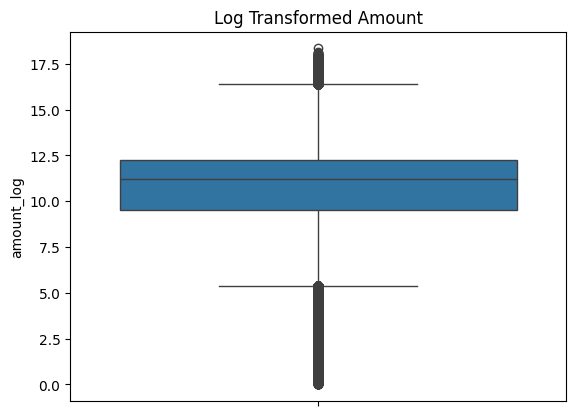

In [12]:
sns.boxplot(y=df['amount_log'])
plt.title("Log Transformed Amount")
plt.show()

In [13]:
df.shape

(6362620, 12)

## EDA

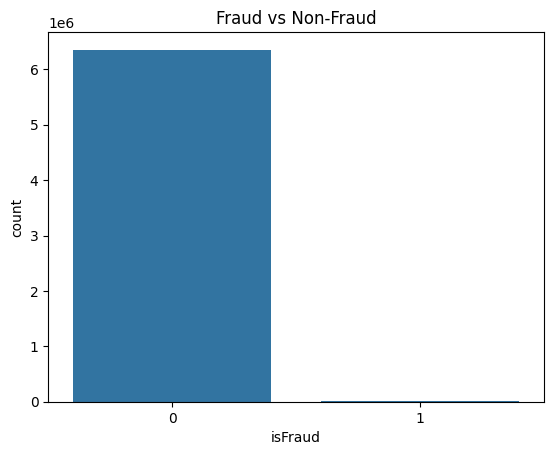

In [14]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

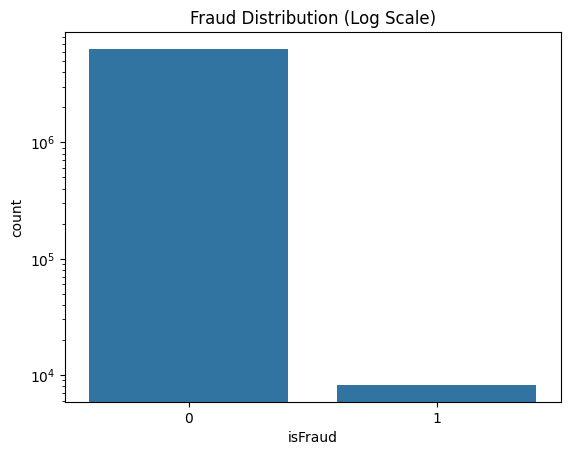

In [15]:
#transformed to log
sns.countplot(x='isFraud', data=df)
plt.yscale('log')
plt.title("Fraud Distribution (Log Scale)")
plt.show()

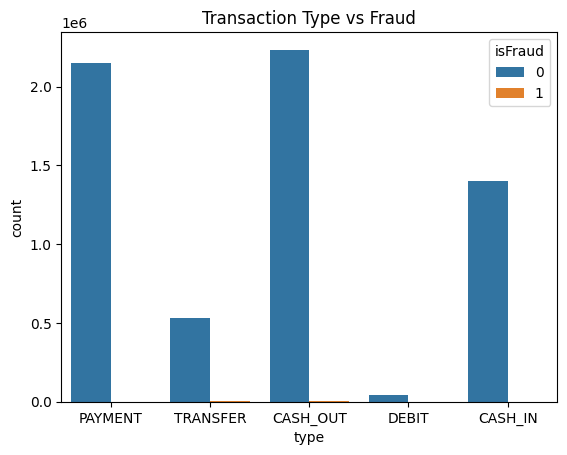

In [16]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Transaction Type vs Fraud")
plt.show()

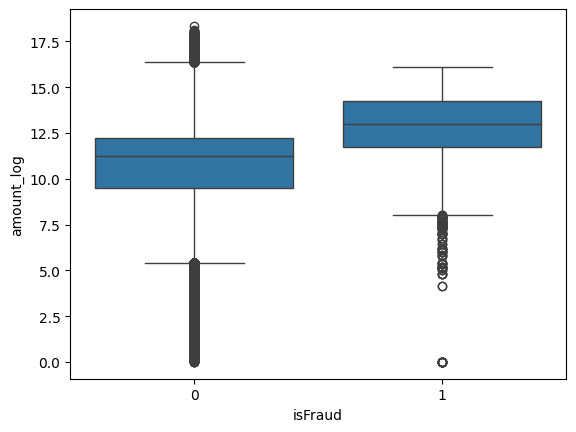

In [17]:
sns.boxplot(x='isFraud', y='amount_log', data=df)
plt.show()

In [18]:
df['org_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

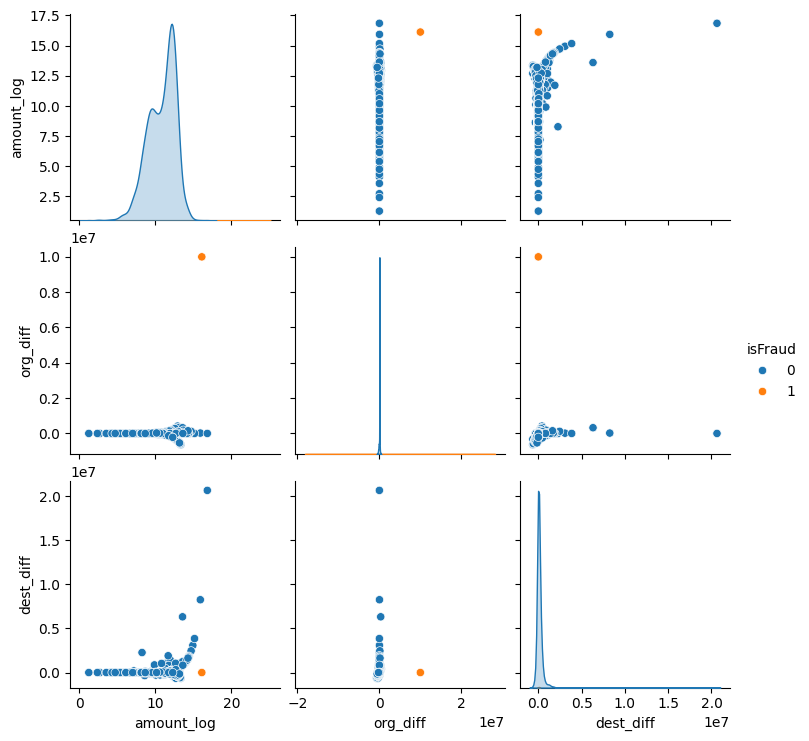

In [19]:
df_sample = df.sample(2000)  
sns.pairplot(df_sample[['amount_log','org_diff','dest_diff','isFraud']], hue='isFraud')
plt.show()

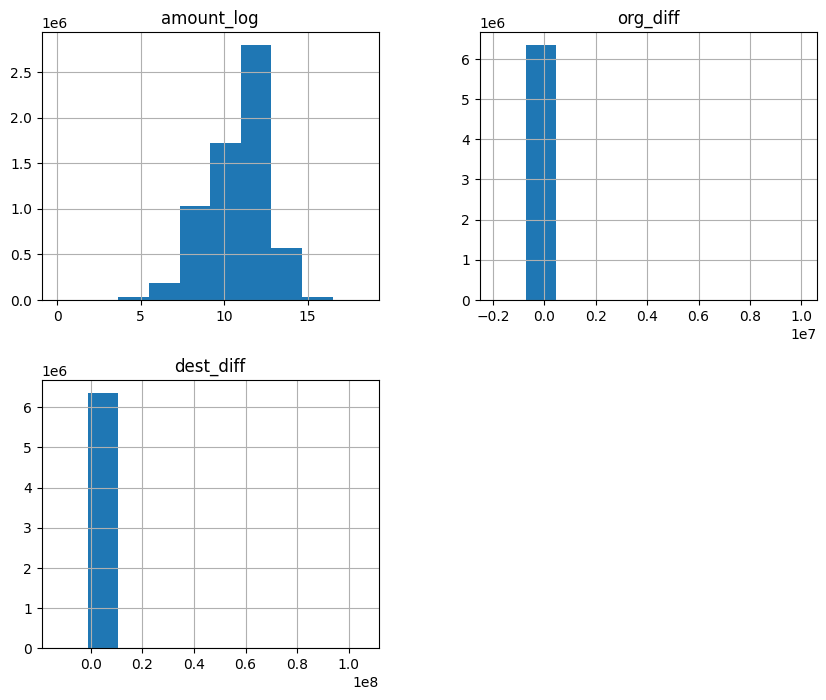

In [20]:
df[['amount_log','org_diff','dest_diff']].hist(figsize=(10,8))
plt.show()

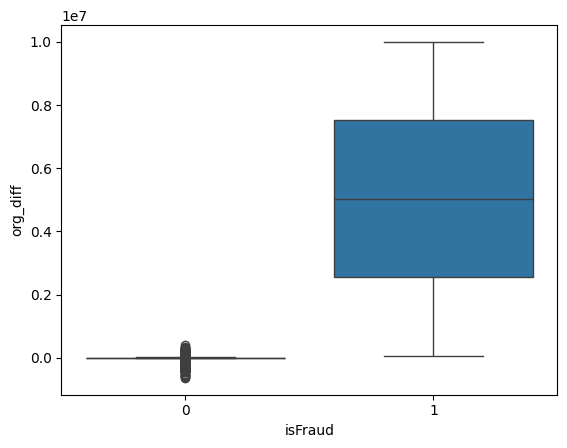

In [21]:
sns.boxplot(x='isFraud', y='org_diff', data=df_sample)
plt.show()

In [22]:
#one hot encoding
df = pd.get_dummies(df, columns=['type'], drop_first=True)
df

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_log,org_diff,dest_diff,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,9.194276,9839.64,0.00,False,False,True,False
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,7.531166,1864.28,0.00,False,False,True,False
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,5.204007,181.00,0.00,False,False,False,True
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,5.204007,181.00,-21182.00,True,False,False,False
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,9.364703,11668.14,0.00,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,12.735768,339682.13,339682.13,True,False,False,False
6362616,743,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,15.657870,6311409.28,0.00,False,False,False,True
6362617,743,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,15.657870,6311409.28,6311409.27,True,False,False,False
6362618,743,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,13.652996,850002.52,0.00,False,False,False,True


In [23]:
#dropping columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)

In [24]:
X = df.drop('isFraud', axis=1)
Y = df['isFraud']

## Logistic Regression

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [26]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, Y_train)

y_pred_lr = lr.predict(X_test)

AS_LR = accuracy_score(Y_test, y_pred_lr)

print("Logistic Regression Accuracy:", AS_LR)

Logistic Regression Accuracy: 0.9992141602044441


In [27]:
print("Classification Report:")
print(classification_report(Y_test, y_pred_lr,zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.85      0.47      0.60      1620

    accuracy                           1.00   1272524
   macro avg       0.92      0.73      0.80   1272524
weighted avg       1.00      1.00      1.00   1272524



In [28]:
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_lr))


Confusion Matrix:
[[1270766     138]
 [    862     758]]


## Random Forest Classifier

In [29]:
df_fraud = df[df['isFraud'] == 1]
df_nonfraud = df[df['isFraud'] == 0].sample(50000)

df_balanced = pd.concat([df_fraud, df_nonfraud])

In [46]:
X_bal = df_balanced.drop('isFraud', axis=1)
Y_bal = df_balanced['isFraud']

x_train, x_test, y_train, y_test = train_test_split(X_bal, Y_bal, test_size=0.2, random_state=42)

In [42]:
# rf = RandomForestClassifier(random_state=42,class_weight='balanced')

# rf.fit(X_train, Y_train)

# y_pred_rf = rf.predict(X_test)
# AS_RF=accuracy_score(Y_test, y_pred_rf)
# print("Random Forest Accuracy:",AS_RF)
rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [48]:
AS_RF = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accracy: ",AS_RF)

Random Forest Accracy:  0.9899510435454779


In [49]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9990
           1       0.98      0.94      0.96      1653

    accuracy                           0.99     11643
   macro avg       0.99      0.97      0.98     11643
weighted avg       0.99      0.99      0.99     11643



In [50]:
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_rf))

Confusion Matrix:
[[9966   24]
 [  93 1560]]


In [51]:
print("Logistic Regression Accuracy:", AS_LR)
print("Random Forest Accuracy:", AS_RF)

Logistic Regression Accuracy: 0.9992141602044441
Random Forest Accuracy: 0.9899510435454779
